<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=317434779" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/wilfriedtsetse04/neurosight-ai-notebook?scriptVersionId=300807538" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [14]:
import os
import sys
import importlib

# 1. Nettoyage et téléchargement du nouveau pipeline
# Remplace par l'URL de ta branche où tu vas pousser le nouveau data_pipeline.py
GITHUB_RAW_URL = "https://raw.githubusercontent.com/wekt2k04/NeuroSight_AI/dev-leila2/notebooks/data_pipeline.py"

print("📥 Mise à jour du pipeline NeuroSight...")
!wget -q -O data_pipeline.py {GITHUB_RAW_URL}

if '/kaggle/working' not in sys.path:
    sys.path.append('/kaggle/working')

# 2. Importation dynamique
try:
    import data_pipeline
    importlib.reload(data_pipeline)
    from data_pipeline import prepare_data, show_sample_batch, plot_class_distribution
    print("✅ Pipeline 'Feature Engineered' chargé avec succès.")
except Exception as e:
    print(f"❌ Erreur d'import : {e}")

📥 Mise à jour du pipeline NeuroSight...
✅ Pipeline 'Feature Engineered' chargé avec succès.


In [16]:
# --- CONFIGURATION DES CHEMINS ---
# Assure-toi que ces chemins correspondent à tes inputs Kaggle
CSV_PATH = '/kaggle/input/datasets/wilfriedtsetse04/mon-csv-officiel/oasis_cross-sectional-5708aa0a98d82080.xlsx'
IMAGES_DIR = '/kaggle/input/datasets/ninadaithal/imagesoasis/Data'

# --- CRÉATION DES LOADERS ---
# Note : on utilise la nouvelle fonction 'prepare_data'

# train_loader, val_loader, test_loader, classes = prepare_data(
#     csv_path=CSV_PATH, 
#     images_dir=IMAGES_DIR, 
#     batch_size=32
# )

# Prepare data with balanced test set
# train_loader, val_loader, test_loader, classes = prepare_data(
#     csv_path=CSV_PATH,
#     images_dir=IMAGES_DIR,
#     batch_size=32,
#     val_split=0.15,
#     test_split=0.15,
#     target_train_per_class=5000,
#     target_test_per_class=50  # Ensures at least 50 Moderate Demented samples in test
# )

# # Verify the test set has all classes
# plot_class_distribution(test_loader, classes)

# The updated prepare_data returns 5 values:
# train_loader, val_loader, test_loader, class_weights, class_names

train_loader, val_loader, test_loader, class_weights, classes = prepare_data(
    csv_path=CSV_PATH,
    images_dir=IMAGES_DIR,
    batch_size=32,
    target_train_per_class=5000,
    target_test_per_class=50,
    class_weight_method='focus'  # 'balanced' or 'focus'
)

print(f"\n📊 Class weights for loss function: {class_weights.numpy()}")
print(f"   Classes: {classes}")

# Then train as before, but evaluate on test_loader at the end

# # --- AUDIT VISUEL ---
# print(f"\n🚀 Classes prêtes : {classes}")
# plot_class_distribution(train_loader, classes)
# show_sample_batch(train_loader, classes)

📖 Loading clinical data + MICE imputation...
   ✅ MICE imputation done.
🔍 Scanning images: /kaggle/input/datasets/ninadaithal/imagesoasis/Data
   ✅ 47580 images linked.

🛡️ Stratified Group Split (patient-level, class-balanced)...

📊 INITIAL SPLIT STATISTICS:
   Train: {0: np.int64(20252), 1: np.int64(10004), 2: np.int64(3599), 3: np.int64(244)}
   Val: {0: np.int64(4087), 1: np.int64(1891), 2: np.int64(671), 3: np.int64(244)}
   Test: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732)}

🔄 Ensuring test set has all classes...

   Original test counts: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732)}
   Moved 50 samples of class 3 from train to test
   New test counts: {0: np.int64(4026), 1: np.int64(1830), 2: np.int64(732), 3: np.int64(50)}

⚖️ STAGE 1: Balancing TRAIN set to 5000 samples per class...
   Class 0: undersampled from 20252 to 5000
   Class 1: undersampled from 10004 to 5000
   Class 2: oversampled from 3599 to 5000
   Class 3: oversampled from 194 to 5000

  


🖥️ DEVICE: cuda

🚀 STAGE 1: TRAINING CLASSIFIER HEAD
   Dropout: 0.8
   Warmup epochs: 20
   LR Head: 5e-05
   LR Backbone: 5e-07

📌 Epoch 1/60
----------------------------------------
Train Loss: 0.7258
Val Loss  : 0.4890
Val Macro-F1: 0.1452
Per-class F1: N=0.156, V=0.217, M=0.127, Mod=0.081
Best F1   : 0.0000
Patience  : 0/10
✅ New best model saved

📌 Epoch 2/60
----------------------------------------
Train Loss: 0.6553
Val Loss  : 0.4856
Val Macro-F1: 0.1638
Per-class F1: N=0.201, V=0.303, M=0.081, Mod=0.070
Best F1   : 0.1452
Patience  : 0/10
✅ New best model saved

📌 Epoch 3/60
----------------------------------------
Train Loss: 0.6331
Val Loss  : 0.4784
Val Macro-F1: 0.1923
Per-class F1: N=0.359, V=0.284, M=0.085, Mod=0.041
Best F1   : 0.1638
Patience  : 0/10
✅ New best model saved

📌 Epoch 4/60
----------------------------------------
Train Loss: 0.6168
Val Loss  : 0.4821
Val Macro-F1: 0.1937
Per-class F1: N=0.341, V=0.290, M=0.078, Mod=0.067
Best F1   : 0.1923
Patience  : 0

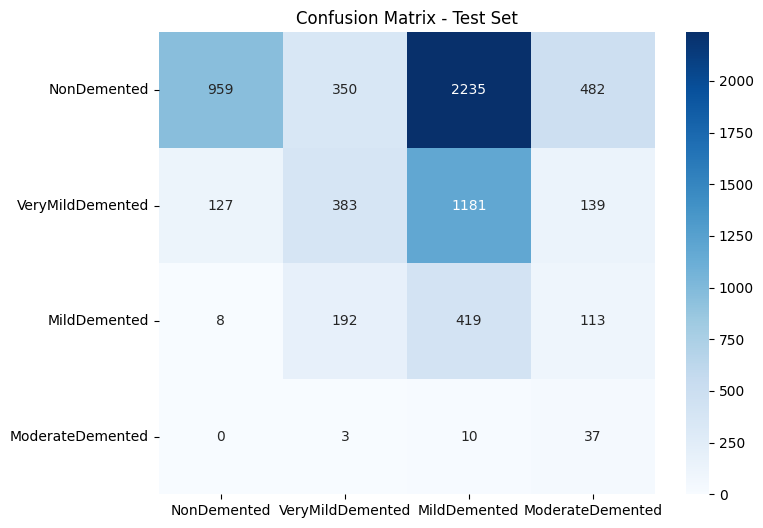

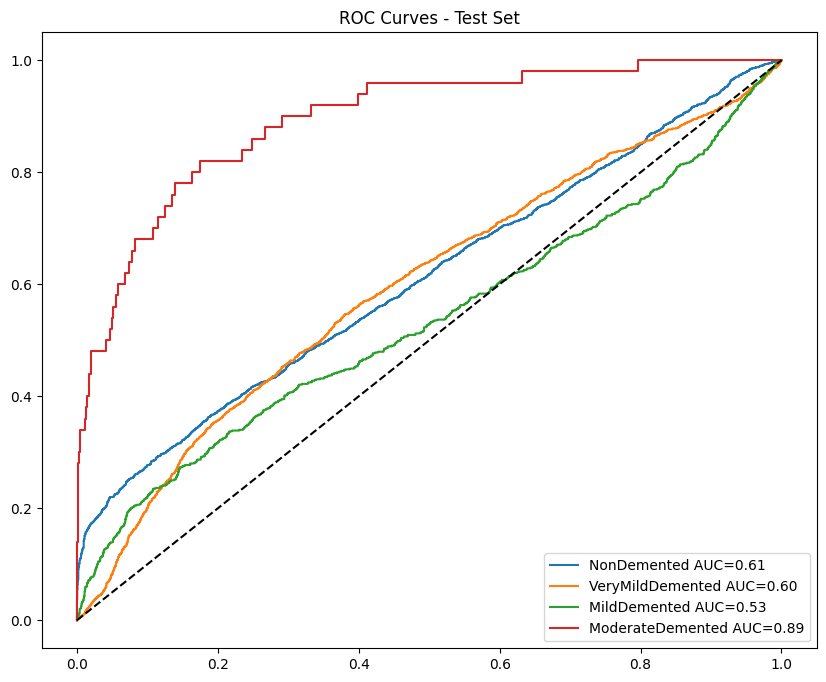


📊 Per-Class Performance:
--------------------------------------------------
NonDemented          | Precision: 0.8766 | Recall: 0.2382 | F1: 0.3746
VeryMildDemented     | Precision: 0.4127 | Recall: 0.2093 | F1: 0.2777
MildDemented         | Precision: 0.1090 | Recall: 0.5724 | F1: 0.1831
ModerateDemented     | Precision: 0.0480 | Recall: 0.7400 | F1: 0.0901
--------------------------------------------------
Macro AVG     | Precision: 0.3616 | Recall: 0.4400 | F1: 0.2314
Weighted AVG  | Precision: 0.6578 | Recall: 0.2709 | F1: 0.3246


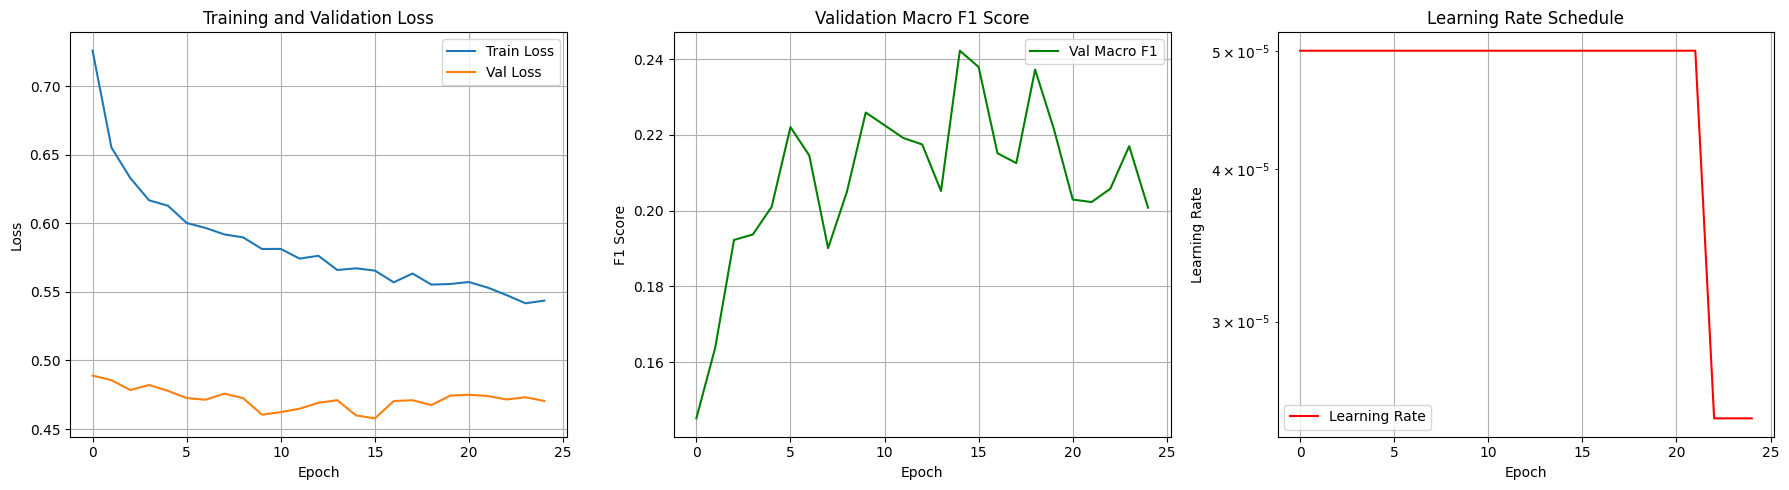


📊 Optimal Thresholds for Each Class:
   NonDemented: 0.30
   VeryMildDemented: 0.30
   MildDemented: 0.30
   ModerateDemented: 0.30

✅ Model saved to 'neurosight_model_final.pth'


In [18]:
# ==========================================================
# CELLULE 3 : ENTRAÎNEMENT & AUDIT DES MÉTRIQUES (FINAL FIXED VERSION)
# With Two-Stage Fine-Tuning and Class Weights
# ==========================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, recall_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn.functional as F


# ==========================================================
# FOCAL LOSS WITH CLASS WEIGHTS
# ==========================================================
class WeightedFocalLoss(nn.Module):
    def __init__(self, class_weights=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = gamma
        self.ls = label_smoothing
        self.class_weights = class_weights

    def forward(self, logits, targets):
        # Move class_weights to same device as logits if provided
        if self.class_weights is not None:
            device = logits.device
            class_weights = self.class_weights.to(device)
        else:
            class_weights = None
            
        ce = F.cross_entropy(
            logits,
            targets,
            reduction='none',
            weight=class_weights,
            label_smoothing=self.ls
        )
        pt = torch.exp(-ce)
        focal_weight = (1 - pt) ** self.gamma
        return (focal_weight * ce).mean()


# ==========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️ DEVICE: {device}")


# ==========================================================
# MODEL - WITH HIGH DROPOUT
# ==========================================================
def build_neurosight_model(num_classes, dropout=0.8):
    model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.IMAGENET1K_V1)
    
    for p in model.parameters():
        p.requires_grad = False

    in_f = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_f, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(inplace=True),
        nn.Dropout(dropout / 2),
        nn.Linear(512, num_classes),
    )
    return model.to(device)


def unfreeze_top_blocks(model, num_blocks=1):
    layers = list(model.features.children())
    for layer in layers[-num_blocks:]:
        for p in layer.parameters():
            p.requires_grad = True


# ==========================================================
# TWO-STAGE TRAINING
# ==========================================================
def train_stage_one(model, train_loader, val_loader, class_weights,
                    num_epochs=60, warmup_epochs=20, patience=10,
                    lr_head=5e-5, lr_backbone=5e-7):

    print("\n🚀 STAGE 1: TRAINING CLASSIFIER HEAD")
    print("=" * 60)
    print(f"   Dropout: 0.8")
    print(f"   Warmup epochs: {warmup_epochs}")
    print(f"   LR Head: {lr_head}")
    print(f"   LR Backbone: {lr_backbone}")
    print("=" * 60)

    # Move class_weights to device
    class_weights = class_weights.to(device)
    criterion = WeightedFocalLoss(class_weights=class_weights, gamma=2.0, label_smoothing=0.1)

    optimizer = optim.AdamW([
        {'params': model.classifier.parameters(), 'lr': lr_head, 'weight_decay': 1e-4},
        {'params': model.features.parameters(), 'lr': 0.0, 'weight_decay': 1e-4},
    ], weight_decay=1e-4)

    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_f1 = 0.0
    best_weights = None
    epochs_no_improve = 0

    history = {"train_loss": [], "val_loss": [], "val_f1": [], "learning_rates": []}

    for epoch in range(num_epochs):
        if epoch == warmup_epochs:
            print("\n🔓 PHASE 2: UNFREEZING BACKBONE")
            unfreeze_top_blocks(model, num_blocks=1)
            optimizer.param_groups[1]['lr'] = lr_backbone
            print(f"   Backbone LR set to: {lr_backbone}")

        print(f"\n📌 Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        val_loss = 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                preds = outputs.argmax(1)
                val_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_f1"].append(val_f1)
        history["learning_rates"].append(optimizer.param_groups[0]['lr'])

        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss  : {avg_val_loss:.4f}")
        print(f"Val Macro-F1: {val_f1:.4f}")
        print(f"Per-class F1: N={per_class_f1[0]:.3f}, V={per_class_f1[1]:.3f}, M={per_class_f1[2]:.3f}, Mod={per_class_f1[3]:.3f}")
        print(f"Best F1   : {best_f1:.4f}")
        print(f"Patience  : {epochs_no_improve}/{patience}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "best_stage1.pth")
            epochs_no_improve = 0
            print("✅ New best model saved")
        else:
            epochs_no_improve += 1

        scheduler.step(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        if len(history["learning_rates"]) > 1 and current_lr != history["learning_rates"][-2]:
            print(f"📉 Learning rate reduced to: {current_lr}")

        if epochs_no_improve >= patience:
            print("\n🛑 EARLY STOPPING TRIGGERED")
            break

    if best_weights is not None:
        model.load_state_dict(best_weights)
    return model, history


def fine_tune_stage_two(model, train_loader, val_loader, class_weights, num_epochs=15):
    """Stage 2: Fine-tune classifier only with higher focus on Mild/Moderate"""
    print("\n🚀 STAGE 2: FINE-TUNING FOR HARD CLASSES")
    print("=" * 60)
    
    # Freeze backbone again
    for p in model.features.parameters():
        p.requires_grad = False
    
    # Even higher weights for Mild and Moderate
    enhanced_weights = class_weights.clone()
    enhanced_weights[2] *= 1.5  # Extra weight for Mild
    enhanced_weights[3] *= 1.5  # Extra weight for Moderate
    enhanced_weights = enhanced_weights / enhanced_weights.sum() * 4
    enhanced_weights = enhanced_weights.to(device)
    
    criterion = WeightedFocalLoss(class_weights=enhanced_weights, gamma=2.0, label_smoothing=0.1)
    
    # Lower learning rate for fine-tuning
    optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-5, weight_decay=1e-4)
    
    best_f1 = 0
    best_weights = None
    
    for epoch in range(num_epochs):
        print(f"\n📌 Fine-tune Epoch {epoch+1}/{num_epochs}")
        print("-" * 40)
        
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = outputs.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
        
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Macro-F1: {val_f1:.4f}")
        print(f"Per-class F1: N={per_class_f1[0]:.3f}, V={per_class_f1[1]:.3f}, M={per_class_f1[2]:.3f}, Mod={per_class_f1[3]:.3f}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            print("✅ New best model saved")
    
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return model


# ==========================================================
# EVALUATION FUNCTION
# ==========================================================
def evaluate_on_test(model, test_loader, class_names):
    print("\n📋 FINAL CLINICAL REPORT - TEST SET")
    print("=" * 60)

    model.eval()
    y_true, y_pred, y_probs = [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_probs = np.array(y_probs)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        if np.sum(y_true_bin[:, i]) > 0:
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{class_names[i]} AUC={roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("ROC Curves - Test Set")
    plt.legend()
    plt.show()
    
    from sklearn.metrics import precision_recall_fscore_support
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    
    print("\n📊 Per-Class Performance:")
    print("-" * 50)
    for i, name in enumerate(class_names):
        print(f"{name:20} | Precision: {precision[i]:.4f} | Recall: {recall[i]:.4f} | F1: {f1[i]:.4f}")
    
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    print("-" * 50)
    print(f"Macro AVG     | Precision: {macro_precision:.4f} | Recall: {macro_recall:.4f} | F1: {macro_f1:.4f}")
    print(f"Weighted AVG  | Precision: {weighted_precision:.4f} | Recall: {weighted_recall:.4f} | F1: {weighted_f1:.4f}")
    
    return y_true, y_pred, y_probs


# ==========================================================
# PLOT TRAINING HISTORY
# ==========================================================
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history['val_f1'], label='Val Macro F1', color='green')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title('Validation Macro F1 Score')
    axes[1].legend()
    axes[1].grid(True)
    
    axes[2].plot(history['learning_rates'], label='Learning Rate', color='red')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_yscale('log')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    plt.show()


# ==========================================================
# OPTIMIZE THRESHOLDS
# ==========================================================
def optimize_thresholds(model, val_loader, class_names):
    """Find optimal confidence thresholds for each class"""
    print("\n🎯 OPTIMIZING CLASS THRESHOLDS")
    print("=" * 60)
    
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    
    best_thresholds = []
    for i, name in enumerate(class_names):
        best_f1 = 0
        best_thresh = 0.5
        
        for thresh in np.arange(0.3, 0.8, 0.05):
            preds = (all_probs[:, i] > thresh).astype(int)
            true = (all_labels == i).astype(int)
            f1 = f1_score(true, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh
        
        best_thresholds.append(best_thresh)
        print(f"{name:20}: threshold={best_thresh:.2f}, F1={best_f1:.3f}")
    
    return best_thresholds


# ==========================================================
# MAIN EXECUTION
# ==========================================================

# Note: Make sure prepare_data has already been called and returned:
# train_loader, val_loader, test_loader, class_weights, classes

# Build model with higher dropout
model = build_neurosight_model(len(classes), dropout=0.8)

# Stage 1: Train classifier head
model, history = train_stage_one(
    model,
    train_loader,
    val_loader,
    class_weights,
    num_epochs=60,
    warmup_epochs=20,
    patience=10,
    lr_head=5e-5,
    lr_backbone=5e-7
)

# Stage 2: Fine-tune for hard classes
model = fine_tune_stage_two(model, train_loader, val_loader, class_weights, num_epochs=15)

# Optimize thresholds
best_thresholds = optimize_thresholds(model, val_loader, classes)

# Final evaluation on test set
print("\n" + "="*60)
print("FINAL EVALUATION ON HELD-OUT TEST SET")
print("="*60)

y_true, y_pred, y_probs = evaluate_on_test(model, test_loader, classes)

# Plot training history
plot_training_history(history)

# Print best thresholds
print("\n📊 Optimal Thresholds for Each Class:")
for i, name in enumerate(classes):
    print(f"   {name}: {best_thresholds[i]:.2f}")

# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'class_names': classes,
    'best_thresholds': best_thresholds,
}, 'neurosight_model_final.pth')
print("\n✅ Model saved to 'neurosight_model_final.pth'")

# Metrics analysis
#### The core problem is **severe overfitting** The model essentially memorised the training set:

    -Train accuracy: 99.9% — Val accuracy: 66.6% (a 33-point gap)
    -Train loss: 0.004 — Val loss: 2.17 (val loss rose monotonically from epoch 1)
    -Per-class F1: NonDemented (0.78), VeryMild (0.51), Mild (0.14), Moderate (0.00 — no samples even reached the val set)
    -Macro F1 only 0.36 — useless for a clinical tool that must detect all severity stages

## The four root causes: 
    -(1) full fine-tuning from epoch 1 destroys pretrained features too quickly, 
    -(2) no early stopping
    -(3) weak augmentation
    -(4) class imbalance in the validation split means Moderate Dementia literally never appears in evaluation.
